In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import os

In [2]:
class Dataset:
    def __init__(self, train_dir, val_dir, batch_size):
        self.train_dir = train_dir
        self.val_dir = val_dir
        self.batch_size = batch_size

        self.train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), 
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def get_loaders(self):
        train_dataset = datasets.ImageFolder(self.train_dir, transform=self.train_transform)
        val_dataset = datasets.ImageFolder(self.val_dir, transform=self.val_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)
        return train_loader, val_loader, train_dataset.classes


In [3]:
class Trainer:
    def __init__(self, model, device, lr, patience):
        self.model = model
        self.device = device
        self.patience = patience
        self.criterion = nn.CrossEntropyLoss()
        
        # IMPROVED: Lowered weight_decay from 1e-3 to 5e-4 to allow faster initial learning
        self.optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
        
        self.scheduler = None
        self.best_accuracy = 0.0
        self.early_stopping_counter = 0

    def set_scheduler(self, train_loader, num_epochs):
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=self.optimizer.param_groups[0]['lr'],
            epochs=num_epochs,
            steps_per_epoch=len(train_loader),
            pct_start=0.2, # Start annealing earlier to stabilize learning
            anneal_strategy='cos'
        )

    def train_one_epoch(self, train_loader):
        self.model.train()
        total_loss, total_correct, total_samples = 0, 0, 0
        for data, targets in train_loader:
            data, targets = data.to(self.device), targets.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            
            if self.scheduler is not None:
                self.scheduler.step()
                
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_correct += predicted.eq(targets).sum().item()
            total_samples += targets.size(0)
            
        return total_loss / len(train_loader), 100. * total_correct / total_samples

    def train(self, train_loader, val_loader, num_epochs, validator, saver, class_names):
        self.set_scheduler(train_loader, num_epochs)
        for epoch in range(num_epochs):
            print(f"\nEpoch [{epoch+1}/{num_epochs}]")
            train_loss, train_acc = self.train_one_epoch(train_loader)
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            
            val_loss, val_acc = validator.validate(val_loader, self.model, self.device, self.criterion)
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                saver.save(self.model, self.optimizer, epoch, self.best_accuracy, class_names)
                print(f"*** Best model updated: {self.best_accuracy:.2f}% ***")
                self.early_stopping_counter = 0
            else:
                self.early_stopping_counter += 1

            if self.early_stopping_counter >= self.patience:
                print(f"Stopped early. Best Val Acc: {self.best_accuracy:.2f}%")
                break

class Validation:
    def validate(self, val_loader, model, device, criterion):
        model.eval()
        total_loss, total_correct, total_samples = 0, 0, 0
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total_correct += predicted.eq(targets).sum().item()
                total_samples += targets.size(0)
        return total_loss / len(val_loader), 100. * total_correct / total_samples

class ModelSaver:
    @staticmethod
    def save(model, optimizer, epoch, best_accuracy, class_names, save_path="saved_models/best_model.pth"):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_accuracy': best_accuracy,
            'class_names': class_names
        }, save_path)


In [4]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device being used:", device)

    data_loader = Dataset("dataset/train", "dataset/val", batch_size=32)
    train_loader, val_loader, class_names = data_loader.get_loaders()
    num_classes = len(class_names)
    print(f"Detected Classes: {class_names}")

    print("Initializing ResNet18...")
    model = models.resnet18(weights='DEFAULT')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    # IMPROVED: Increased LR to 1e-4 and Patience to 12
    learning_rate = 1e-4  
    num_epoch = 50
    patience = 12 
    
    trainer = Trainer(model, device, lr=learning_rate, patience=patience)
    trainer.train(train_loader, val_loader, num_epoch, Validation(), ModelSaver(), class_names)

if __name__ == "__main__":
    main()

    

Device being used: cuda
Detected Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Initializing ResNet18...

Epoch [1/50]
Train Loss: 1.7723, Train Acc: 26.04%
Val Loss: 1.5006, Val Acc: 42.26%
*** Best model updated: 42.26% ***

Epoch [2/50]
Train Loss: 1.2998, Train Acc: 51.60%
Val Loss: 1.0067, Val Acc: 67.86%
*** Best model updated: 67.86% ***

Epoch [3/50]
Train Loss: 0.8509, Train Acc: 72.81%
Val Loss: 0.6786, Val Acc: 78.77%
*** Best model updated: 78.77% ***

Epoch [4/50]
Train Loss: 0.5727, Train Acc: 81.68%
Val Loss: 0.4392, Val Acc: 86.51%
*** Best model updated: 86.51% ***

Epoch [5/50]
Train Loss: 0.4220, Train Acc: 87.26%
Val Loss: 0.2996, Val Acc: 90.87%
*** Best model updated: 90.87% ***

Epoch [6/50]
Train Loss: 0.3152, Train Acc: 89.99%
Val Loss: 0.1648, Val Acc: 95.63%
*** Best model updated: 95.63% ***

Epoch [7/50]
Train Loss: 0.2424, Train Acc: 91.77%
Val Loss: 0.1532, Val Acc: 96.03%
*** Best model updated: 96.03% ***

Epoch [8/50]
Train Loss:

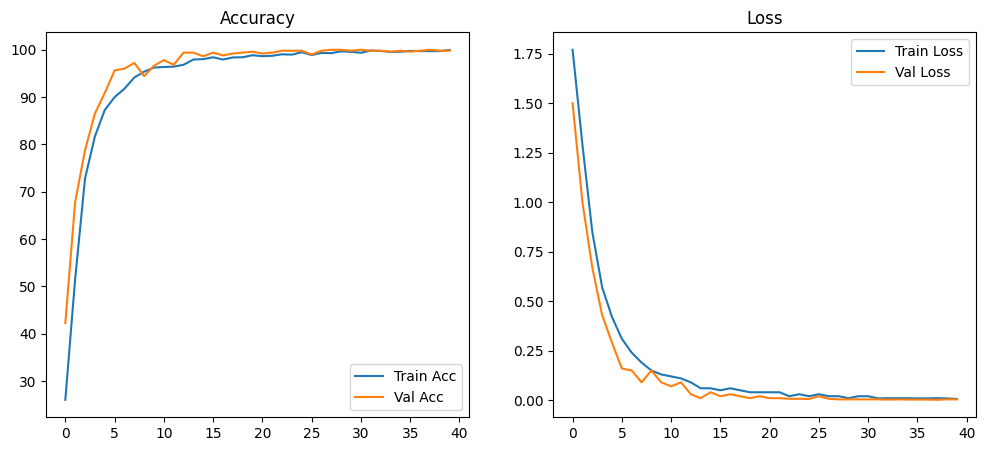

In [7]:
import matplotlib.pyplot as plt

# Manually recreating the history from your successful run
# This allows you to plot without re-running all 40 epochs
history = {
    'train_acc': [26.04, 51.60, 72.81, 81.68, 87.26, 89.99, 91.77, 94.14, 95.37, 96.24, 
                  96.36, 96.44, 96.83, 97.94, 98.02, 98.42, 97.94, 98.38, 98.42, 98.85, 
                  98.65, 98.73, 99.05, 98.97, 99.49, 98.89, 99.33, 99.29, 99.68, 99.56, 
                  99.37, 99.84, 99.76, 99.53, 99.60, 99.76, 99.72, 99.72, 99.72, 99.96],
    'val_acc': [42.26, 67.86, 78.77, 86.51, 90.87, 95.63, 96.03, 97.22, 94.44, 96.63, 
                97.82, 96.83, 99.40, 99.40, 98.61, 99.40, 98.81, 99.21, 99.40, 99.60, 
                99.21, 99.40, 99.80, 99.80, 99.80, 99.01, 99.80, 100.0, 100.0, 99.80, 
                100.0, 99.80, 99.80, 99.60, 99.80, 99.60, 99.80, 100.0, 99.80, 99.80],
    'train_loss': [1.77, 1.29, 0.85, 0.57, 0.42, 0.31, 0.24, 0.19, 0.15, 0.13, 
                   0.12, 0.11, 0.09, 0.06, 0.06, 0.05, 0.06, 0.05, 0.04, 0.04, 
                   0.04, 0.04, 0.02, 0.03, 0.02, 0.03, 0.02, 0.02, 0.01, 0.02, 
                   0.02, 0.009, 0.01, 0.01, 0.01, 0.009, 0.009, 0.01, 0.009, 0.006],
    'val_loss': [1.50, 1.00, 0.67, 0.43, 0.29, 0.16, 0.15, 0.09, 0.15, 0.09, 
                 0.07, 0.09, 0.03, 0.01, 0.04, 0.02, 0.03, 0.02, 0.01, 0.02, 
                 0.01, 0.01, 0.007, 0.007, 0.006, 0.02, 0.007, 0.004, 0.004, 0.004, 
                 0.004, 0.004, 0.003, 0.004, 0.003, 0.003, 0.003, 0.002, 0.004, 0.004]
}

# Now Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt # Added for plotting

In [9]:
class Dataset:
    def __init__(self, train_dir, val_dir, batch_size):
        self.train_dir = train_dir
        self.val_dir = val_dir
        self.batch_size = batch_size

        self.train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), 
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def get_loaders(self):
        train_dataset = datasets.ImageFolder(self.train_dir, transform=self.train_transform)
        val_dataset = datasets.ImageFolder(self.val_dir, transform=self.val_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)
        return train_loader, val_loader, train_dataset.classes

In [10]:
class Trainer:
    def __init__(self, model, device, lr, patience):
        self.model = model
        self.device = device
        self.patience = patience
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
        
        self.scheduler = None
        self.best_accuracy = 0.0
        self.early_stopping_counter = 0

        # --- NEW: History Storage ---
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }

    def set_scheduler(self, train_loader, num_epochs):
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=self.optimizer.param_groups[0]['lr'],
            epochs=num_epochs,
            steps_per_epoch=len(train_loader),
            pct_start=0.2,
            anneal_strategy='cos'
        )

    def train_one_epoch(self, train_loader):
        self.model.train()
        total_loss, total_correct, total_samples = 0, 0, 0
        for data, targets in train_loader:
            data, targets = data.to(self.device), targets.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            
            if self.scheduler is not None:
                self.scheduler.step()
                
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_correct += predicted.eq(targets).sum().item()
            total_samples += targets.size(0)
            
        return total_loss / len(train_loader), 100. * total_correct / total_samples

    def train(self, train_loader, val_loader, num_epochs, validator, saver, class_names):
        self.set_scheduler(train_loader, num_epochs)
        for epoch in range(num_epochs):
            print(f"\nEpoch [{epoch+1}/{num_epochs}]")
            train_loss, train_acc = self.train_one_epoch(train_loader)
            val_loss, val_acc = validator.validate(val_loader, self.model, self.device, self.criterion)
            
            # --- NEW: Automatically Save to History ---
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

            if val_acc > self.best_accuracy:
                self.best_accuracy = val_acc
                saver.save(self.model, self.optimizer, epoch, self.best_accuracy, class_names)
                print(f"*** Best model updated: {self.best_accuracy:.2f}% ***")
                self.early_stopping_counter = 0
            else:
                self.early_stopping_counter += 1

            if self.early_stopping_counter >= self.patience:
                print(f"Stopped early. Best Val Acc: {self.best_accuracy:.2f}%")
                break
        
        # --- NEW: Call Plotting Automatically ---
        self.plot_metrics()

    # --- NEW: Automatic Plotting Function ---
    def plot_metrics(self):
        epochs = range(1, len(self.history['train_acc']) + 1)
        
        plt.figure(figsize=(12, 5))
        
        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['train_acc'], 'b-', label='Train Accuracy')
        plt.plot(epochs, self.history['val_acc'], 'r-', label='Val Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        
        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['train_loss'], 'b-', label='Train Loss')
        plt.plot(epochs, self.history['val_loss'], 'r-', label='Val Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

class Validation:
    def validate(self, val_loader, model, device, criterion):
        model.eval()
        total_loss, total_correct, total_samples = 0, 0, 0
        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                total_loss += loss.item()
                _, predicted = outputs.max(1)
                total_correct += predicted.eq(targets).sum().item()
                total_samples += targets.size(0)
        return total_loss / len(val_loader), 100. * total_correct / total_samples

class ModelSaver:
    @staticmethod
    def save(model, optimizer, epoch, best_accuracy, class_names, save_path="saved_models/best_model.pth"):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_accuracy': best_accuracy,
            'class_names': class_names
        }, save_path)

In [11]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device being used:", device)

    data_loader = Dataset("dataset/train", "dataset/val", batch_size=32)
    train_loader, val_loader, class_names = data_loader.get_loaders()
    num_classes = len(class_names)
    print(f"Detected Classes: {class_names}")

    print("Initializing ResNet18...")
    model = models.resnet18(weights='DEFAULT')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    learning_rate = 1e-4  
    num_epoch = 50
    patience = 12 
    
    trainer = Trainer(model, device, lr=learning_rate, patience=patience)
    trainer.train(train_loader, val_loader, num_epoch, Validation(), ModelSaver(), class_names)

if __name__ == "__main__":
    main()

Device being used: cuda
Detected Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Initializing ResNet18...


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
